In [24]:

import lightkurve as lk
import matplotlib.pyplot as plt


56


In [6]:
search = lk.search_targetpixelfile("NGC7335",mission="TESS")
tpf = search[0].download()
mask = tpf.create_threshold_mask(threshold=5)


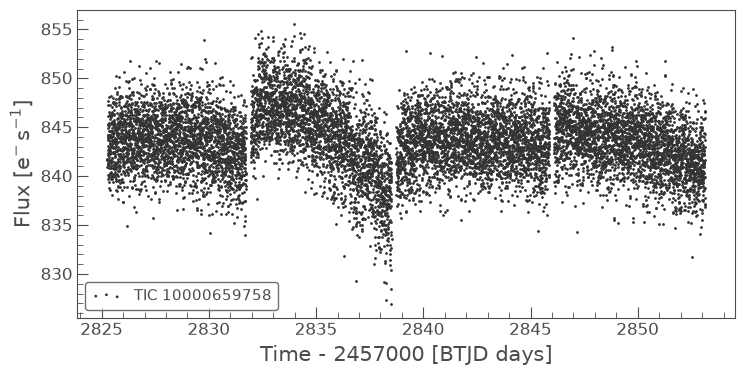

In [7]:
lc = tpf.to_lightcurve(aperture_mask=mask)
lc.scatter()
plt.show()

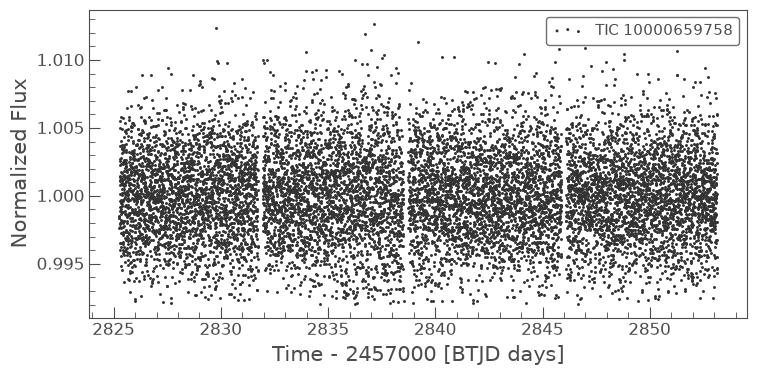

In [73]:
clean = lc.remove_nans()
filtered = clean.remove_outliers()


flatten = filtered.flatten(window_length=301, break_tolerance=100)


flatten = flatten[flatten.flux.value > 0.992]

flatten.scatter(s=5)
plt.show()


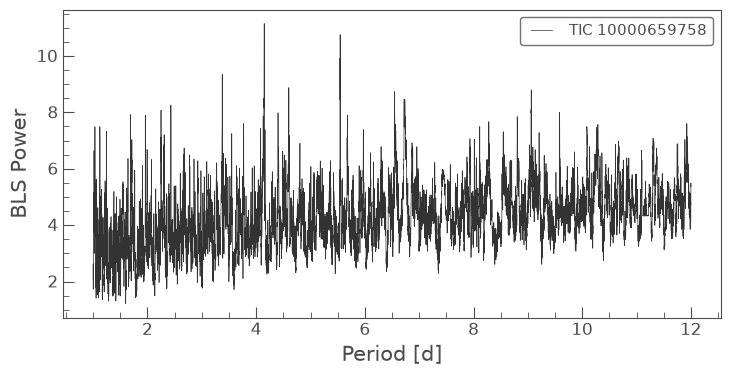

In [74]:
import numpy as np

periodogram = flatten.to_periodogram(method = 'bls', period = np.arange(1,12,0.001))

periodogram.plot()
plt.show()


In [75]:
best_period = periodogram.period_at_max_power
best_t0 = periodogram.transit_time_at_max_power

print("Best period:", best_period)
print("Best t0:", best_t0)

Best period: 4.147999999999653 d
Best t0: 2827.5423112277645


In [76]:
import numpy as np

# 1. Get the raw values as arrays
periods = periodogram.period.value
powers = periodogram.power.value

# 2. Sort them to find the indices of the top 5 highest peaks
top_indices = np.argsort(powers)[-5:][::-1]

# 3. Print a clean summary list you can copy-paste
print("--- TOP 5 HIGHEST PERIODOGRAM PEAKS ---")
for i, idx in enumerate(top_indices, 1):
    print(f"Rank {i} -> Period: {periods[idx]:.4f} days | Power: {powers[idx]:.4f}")


--- TOP 5 HIGHEST PERIODOGRAM PEAKS ---
Rank 1 -> Period: 4.1480 days | Power: 11.1504
Rank 2 -> Period: 5.5450 days | Power: 10.7595
Rank 3 -> Period: 4.1470 days | Power: 10.5262
Rank 4 -> Period: 5.5430 days | Power: 9.9248
Rank 5 -> Period: 5.5420 days | Power: 9.4772


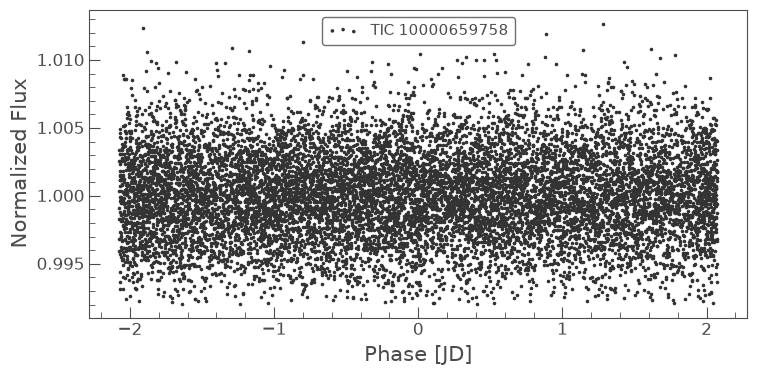

In [77]:
folded_lc = flatten.fold(period=best_period,epoch_time=best_t0)
folded_lc.scatter(s=10)
plt.show()

D:\NASA TESS analysis\.venv\Lib\site-packages\lightkurve\lightcurve.py:3510: UserWarning: n_bins is no longer accepted for FoldedLightCurve objects. Please specify 'bins' instead
  warnings.warn(


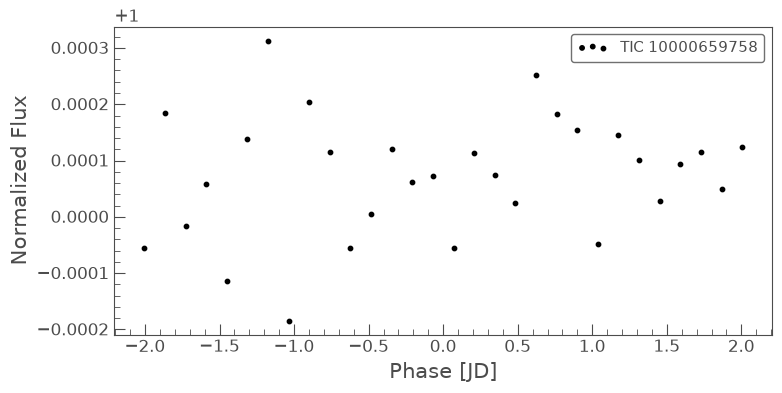

In [79]:

binned = folded_lc.bin(n_bins=30)


binned.scatter(s=40, color='black')

plt.show()